# Full Transmission Spectrum
This notebook will plot the full spectrum of TOI-1130b and will also have a section to write .dat files for each instrument separately below

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import juliet

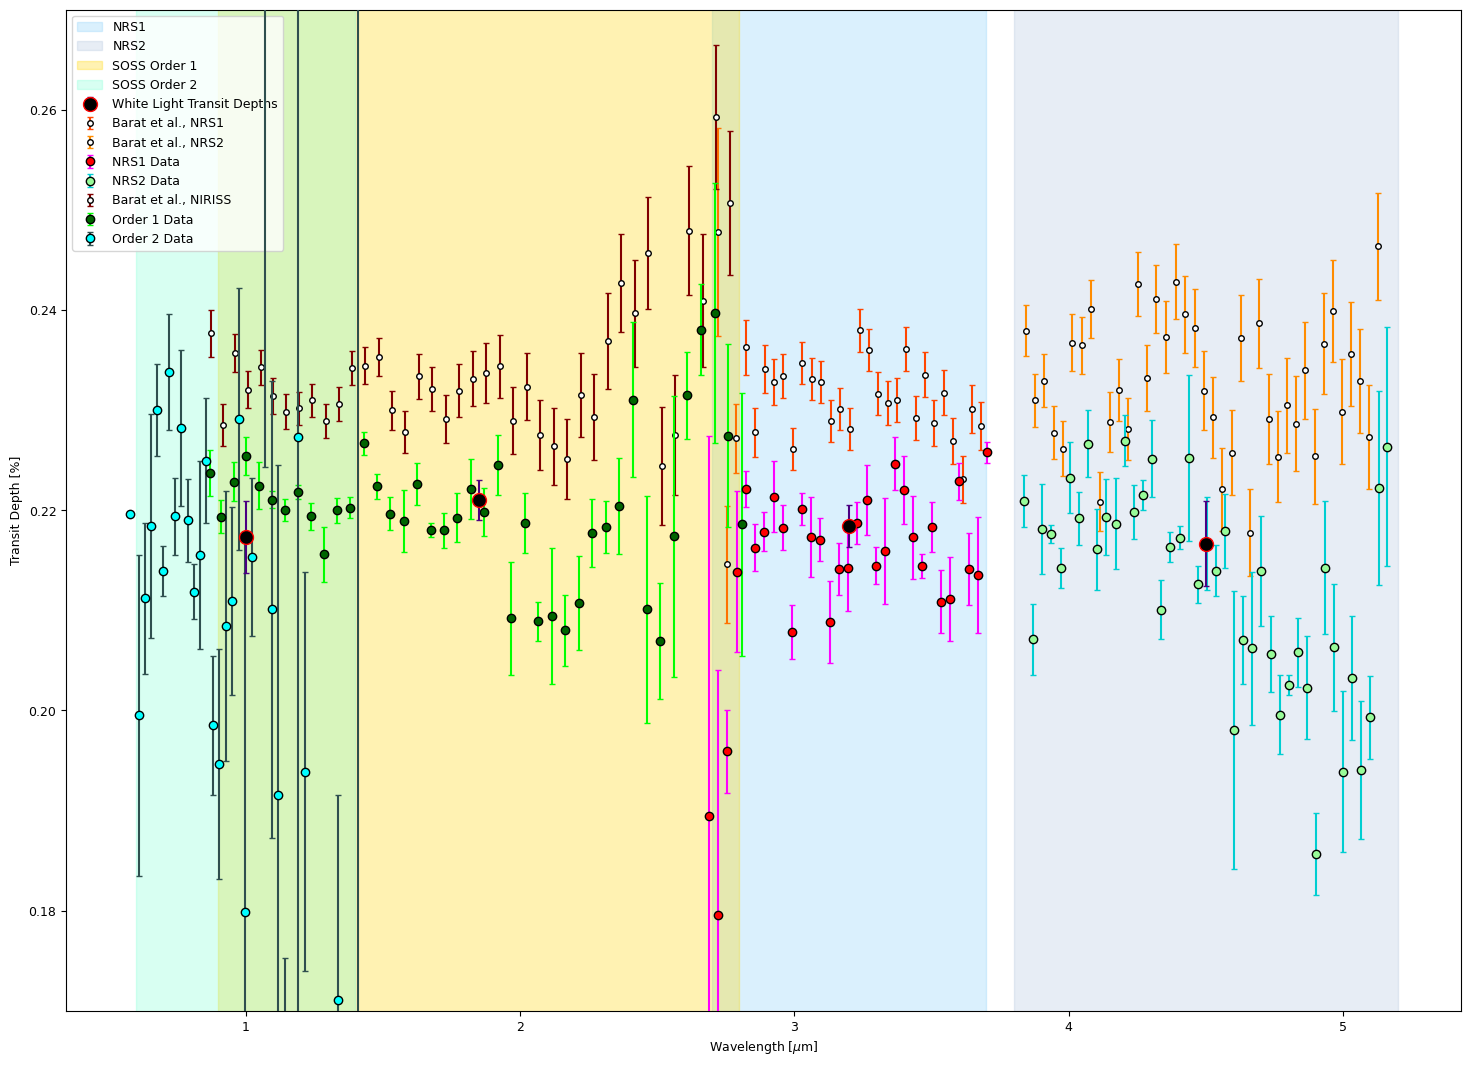

In [2]:
# First iteration of full spectrum
fig = plt.figure(figsize = (18, 13))
# Plot wavlength ranges for each detector
nrs1, nrs2 = [2.7, 3.7], [3.8, 5.2]
ys = [0.10, 0.40]   # Set ylim such that this spans the entire screen
plt.fill_betweenx(ys, nrs1[0], nrs1[1], color = 'lightskyblue', alpha = 0.3, zorder = 1, label = 'NRS1')
plt.fill_betweenx(ys, nrs2[0], nrs2[1], color = 'lightsteelblue', alpha = 0.3, zorder = 1, label = 'NRS2')

# Plot transit depths from white light curves
central_bins = [3.2, 4.5]
central_td = [0.2184226235891346, 0.2166471182659463]
central_tderr = [0.0021033446739131805, 0.004233196717110537]

plt.errorbar(central_bins, central_td, yerr = central_tderr, 
             fmt = 'o', capsize = 2, ms = 10, mfc = 'k', mec = 'r', color = 'indigo', label = 'White Light Transit Depths', zorder = 10)

# Plot spectrum from Barat et al., 2026 for comparison
barat_nrs1 = pd.read_csv('barat_toi1130b_spectrum_nrs1.csv')
barat_wl_nrs1 = barat_nrs1['CENTRALWAVELNG']
barat_td_nrs1 = barat_nrs1['PL_TRANDEP']
barat_tderr_nrs1 = barat_nrs1['PL_TRANDEPERR1']

barat_nrs2 = pd.read_csv('barat_toi1130b_spectrum_nrs2.csv')
barat_wl_nrs2 = barat_nrs2['CENTRALWAVELNG']
barat_td_nrs2 = barat_nrs2['PL_TRANDEP']
barat_tderr_nrs2 = barat_nrs2['PL_TRANDEPERR1']

plt.errorbar(barat_wl_nrs1, barat_td_nrs1, yerr = barat_tderr_nrs1, 
             fmt = 'o', capsize = 2, ms = 4, mfc = 'w', mec = 'k', color = 'orangered', label = 'Barat et al., NRS1', zorder = 1)
plt.errorbar(barat_wl_nrs2, barat_td_nrs2, yerr = barat_tderr_nrs2, 
             fmt = 'o', capsize = 2, ms = 4, mfc = 'w', mec = 'k', color = 'darkorange', label = 'Barat et al., NRS2', zorder = 1)


# NRS 1
nrs1_data = pd.read_csv('TOI-1130b_NRS1-Cluster.csv')
nrs1_wl = np.array(nrs1_data['wavelength'])
nrs1_td = np.array(nrs1_data['transit depth'])
nrs1_tderr = np.array(nrs1_data['transit depth error'])

nrs1_wl, nrs1_td, nrs1_tderr = juliet.bin_data(nrs1_wl, nrs1_td, 5)
plt.errorbar(nrs1_wl, nrs1_td, yerr = nrs1_tderr, 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'r', mec = 'k', color = 'fuchsia', label = 'NRS1 Data', zorder = 8)

# NRS 2
nrs2_data = pd.read_csv('TOI-1130b_NRS2-Cluster.csv')
nrs2_wl = np.array(nrs2_data['wavelength'])
nrs2_td = np.array(nrs2_data['transit depth'])
nrs2_tderr = np.array(nrs2_data['transit depth error'])

nrs2_wl, nrs2_td, nrs2_tderr = juliet.bin_data(nrs2_wl, nrs2_td, 5)
plt.errorbar(nrs2_wl, nrs2_td, yerr = nrs2_tderr, 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'palegreen', mec = 'k', color = 'darkturquoise', label = 'NRS2 Data', zorder = 8)


o1, o2 = [0.9, 2.8], [0.6, 1.4]
ys = [0.10, 0.40]   # This also indirectly sets the ylim
plt.fill_betweenx(ys, o1[0], o1[1], color = 'gold', alpha = 0.3, zorder = 1, label = 'SOSS Order 1')
plt.fill_betweenx(ys, o2[0], o2[1], color = 'aquamarine', alpha = 0.3, zorder = 1, label = 'SOSS Order 2')

# Plot transit depths from white light curves
central_bins = [1.85, 1.0]
central_td = [0.22100553852421323, 0.21729974049462947]
central_tderr = [0.001982675994479956, 0.003600218438427502]

plt.errorbar(central_bins, central_td, yerr = central_tderr, 
             fmt = 'o', capsize = 2, ms = 10, mfc = 'k', mec = 'r', color = 'indigo', zorder = 10)

# Plot spectrum from Barat et al., 2026 for comparison
barat_niriss = pd.read_csv('barat_toi1130b_spectrum_niriss.csv')
barat_wl_niriss = barat_niriss['CENTRALWAVELNG']
barat_td_niriss = barat_niriss['PL_TRANDEP']
barat_tderr_niriss = barat_niriss['PL_TRANDEPERR1']

plt.errorbar(barat_wl_niriss, barat_td_niriss, yerr = barat_tderr_niriss, 
             fmt = 'o', capsize = 2, ms = 4, mfc = 'w', mec = 'k', color = 'maroon', label = 'Barat et al., NIRISS', zorder = 2)

# Order 1
o1_data = pd.read_csv('TOI-1130b_Order1-Cluster.csv')
o1_wl = np.array(o1_data['wavelength'])
o1_td = np.array(o1_data['transit depth'])
o1_tderr = np.array(o1_data['transit depth error'])

o1_wl, o1_td, o1_tderr = juliet.bin_data(o1_wl, o1_td, 5)
plt.errorbar(o1_wl, o1_td, yerr = o1_tderr, 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'darkgreen', mec = 'k', color = 'lime', label = 'Order 1 Data', zorder = 8)

# Order 2
o2_data = pd.read_csv('TOI-1130b_Order2-Cluster.csv')
o2_wl = np.array(o2_data['wavelength'])
o2_td = np.array(o2_data['transit depth'])
o2_tderr = np.array(o2_data['transit depth error'])

o2_wl, o2_td, o2_tderr = juliet.bin_data(o2_wl, o2_td, 5)
plt.errorbar(o2_wl, o2_td, yerr = o2_tderr, 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'aqua', mec = 'k', color = 'darkslategray', label = 'Order 2 Data', zorder = 8)

plt.xlabel('Wavelength [$\mu$m]')
plt.ylabel('Transit Depth [%]')
plt.ylim(0.17, 0.27)
plt.legend()
plt.show()

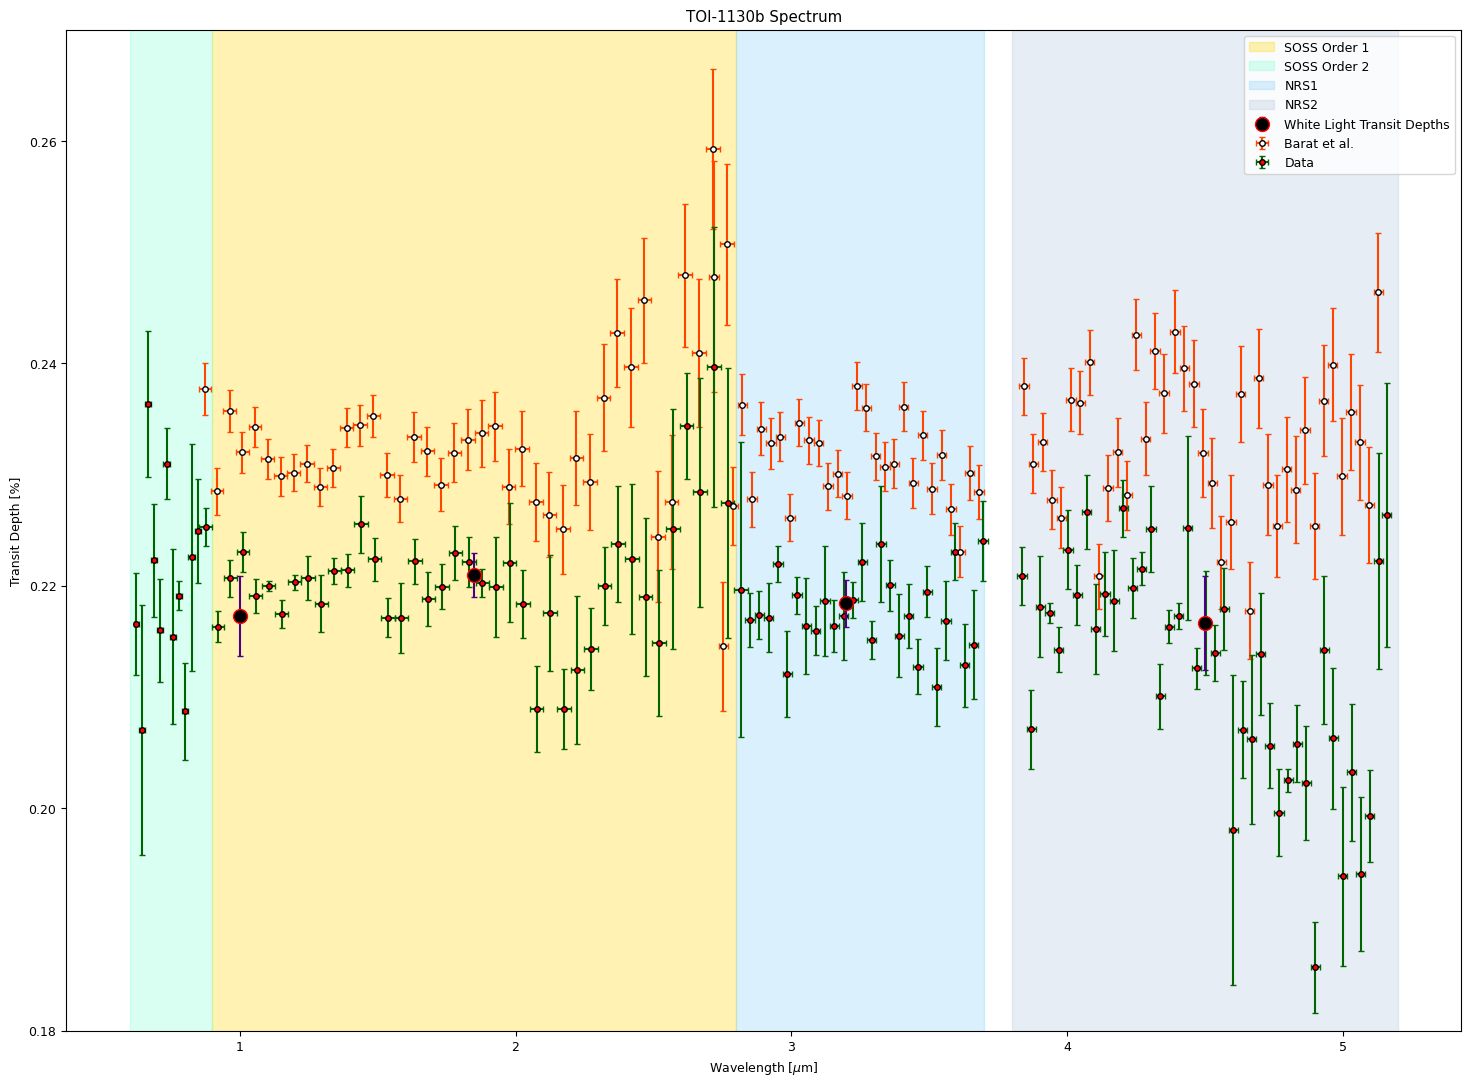

In [19]:
# Use full csvs and cut out overlap for our data
fig = plt.figure(figsize = (18, 13))

# Plot wavlength ranges for each detector
o1, o2 = [0.9, 2.8], [0.6, 0.9]
ys = [0.10, 0.40]  
plt.fill_betweenx(ys, o1[0], o1[1], color = 'gold', alpha = 0.3, zorder = 1, label = 'SOSS Order 1')
plt.fill_betweenx(ys, o2[0], o2[1], color = 'aquamarine', alpha = 0.3, zorder = 1, label = 'SOSS Order 2')
nrs1, nrs2 = [2.8, 3.7], [3.8, 5.2]
ys = [0.10, 0.40] 
plt.fill_betweenx(ys, nrs1[0], nrs1[1], color = 'lightskyblue', alpha = 0.3, zorder = 1, label = 'NRS1')
plt.fill_betweenx(ys, nrs2[0], nrs2[1], color = 'lightsteelblue', alpha = 0.3, zorder = 1, label = 'NRS2')

# Plot transit depths from white light curves
central_bins = [3.2, 4.5]
central_td = [0.2184226235891346, 0.2166471182659463]
central_tderr = [0.0021033446739131805, 0.004233196717110537]
plt.errorbar(central_bins, central_td, yerr = central_tderr, 
             fmt = 'o', capsize = 2, ms = 10, mfc = 'k', mec = 'r', color = 'indigo', label = 'White Light Transit Depths', zorder = 10)
central_bins = [1.85, 1.0]
central_td = [0.22100553852421323, 0.21729974049462947]
central_tderr = [0.001982675994479956, 0.003600218438427502]
plt.errorbar(central_bins, central_td, yerr = central_tderr, 
             fmt = 'o', capsize = 2, ms = 10, mfc = 'k', mec = 'r', color = 'indigo', zorder = 10)

# Barat et al., 2026
barat_full = pd.read_csv('barat_toi1130b_full_spectrum.csv')
barat_wl = np.array(barat_full['wavelength'])
barat_bin = np.array(barat_full['bin width']) / 2
barat_td = np.array(barat_full['transit depth'])
barat_tderr = np.array(barat_full['transit depth error'])

plt.errorbar(barat_wl, barat_td, xerr = barat_bin, yerr = barat_tderr, 
            fmt = 'o', capsize = 2, ms = 4, mfc = 'w', mec = 'k', color = 'orangered', label = 'Barat et al.')

# Data
dat_full = pd.read_csv('TOI-1130b_full_spectrum.csv')
dat_wl, dat_wl1 = np.array(dat_full['wavelength']), np.array(dat_full['wavelength'])
dat_bin = np.array(dat_full['bin width'])
dat_td = np.array(dat_full['transit depth'])
dat_tderr = np.array(dat_full['transit depth error'])

dat_wl, dat_td, dat_tderr = juliet.bin_data(dat_wl, dat_td, 5)
dat_wl1, dat_bin, _ = juliet.bin_data(dat_wl1, dat_bin, 5)

# Cut out first two points: big outliers
dat_wl, dat_bin, dat_td, dat_tderr = dat_wl[2:], dat_bin[2:]*2.5, dat_td[2:], dat_tderr[2:]

plt.errorbar(dat_wl, dat_td, xerr = dat_bin, yerr = dat_tderr, 
            fmt = 'o', capsize = 2, ms = 4, mfc = 'r', mec = 'k', color = 'darkgreen', label = 'Data')

plt.title('TOI-1130b Spectrum')
plt.xlabel('Wavelength [$\mu$m]')
plt.ylabel('Transit Depth [%]')
plt.ylim(0.18, 0.27)
plt.legend()
plt.show()

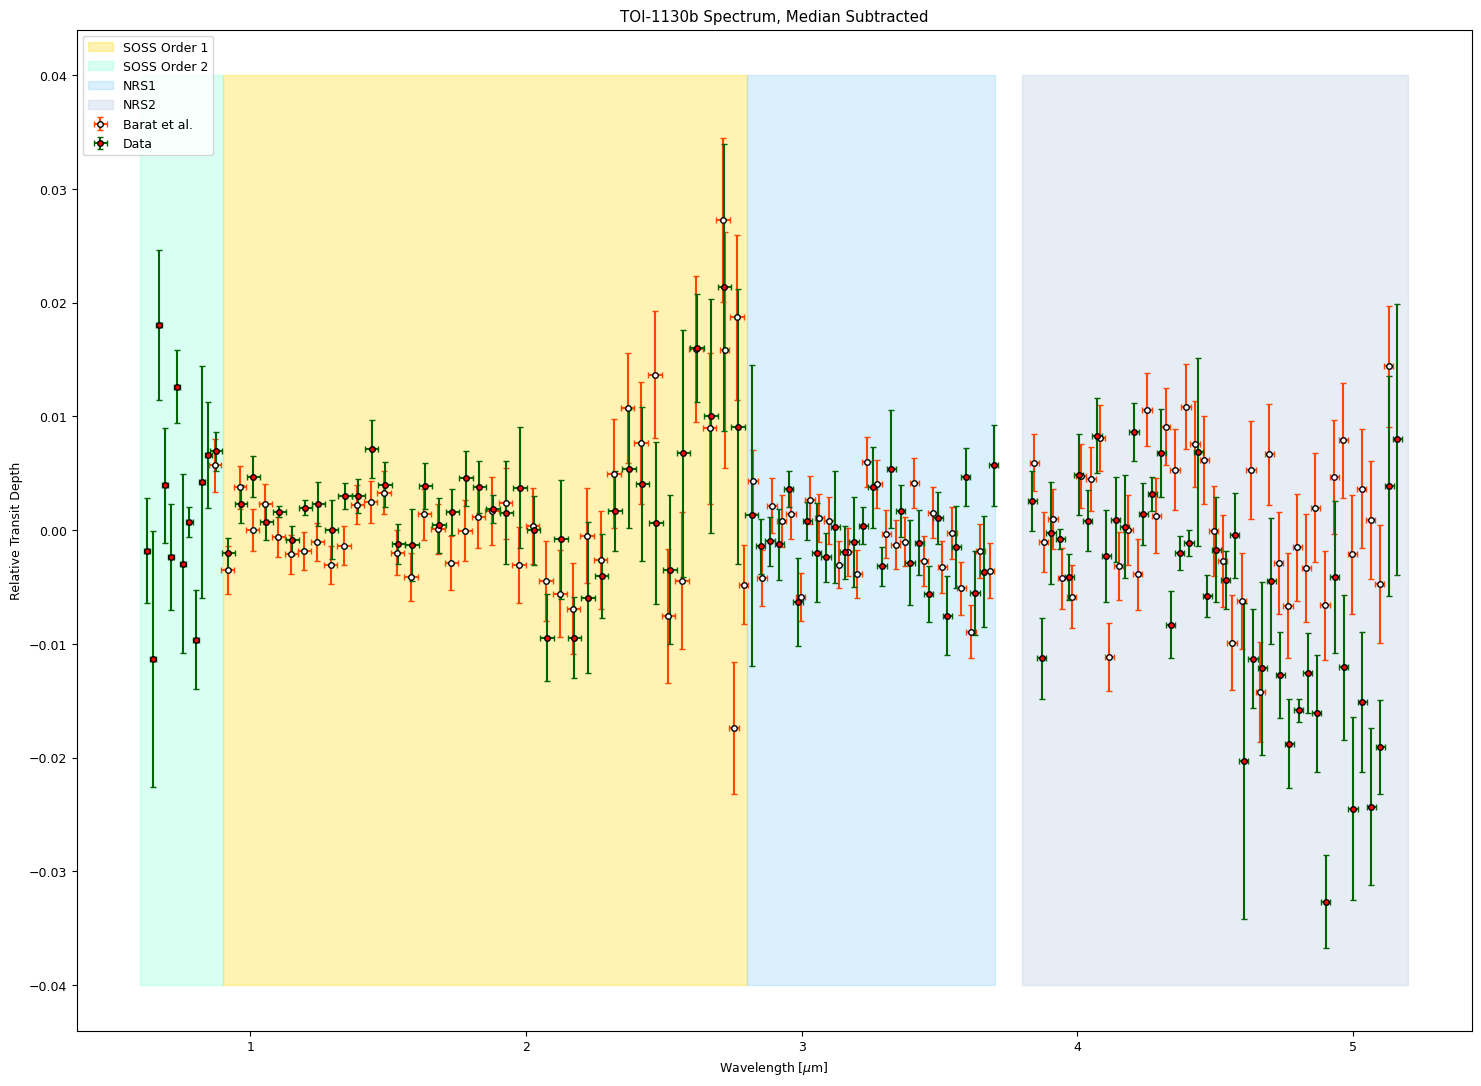

In [55]:
# Divide by mean 
fig = plt.figure(figsize = (18, 13))
b_med = np.nanmedian(barat_td)
d_med = np.nanmedian(dat_td)

b_td_norm = barat_td - b_med
d_td_norm = dat_td - d_med

plt.errorbar(barat_wl, b_td_norm, xerr = barat_bin, yerr = barat_tderr, 
            fmt = 'o', capsize = 2, ms = 4, mfc = 'w', mec = 'k', color = 'orangered', label = 'Barat et al.')

plt.errorbar(dat_wl, d_td_norm, xerr = dat_bin, yerr = dat_tderr, 
            fmt = 'o', capsize = 2, ms = 4, mfc = 'r', mec = 'k', color = 'darkgreen', label = 'Data')

# Plot wavlength ranges for each detector
o1, o2 = [0.9, 2.8], [0.6, 0.9]
ys = [-0.04, 0.04]  
plt.fill_betweenx(ys, o1[0], o1[1], color = 'gold', alpha = 0.3, zorder = 1, label = 'SOSS Order 1')
plt.fill_betweenx(ys, o2[0], o2[1], color = 'aquamarine', alpha = 0.3, zorder = 1, label = 'SOSS Order 2')
nrs1, nrs2 = [2.8, 3.7], [3.8, 5.2]
ys = [-0.04, 0.04]  
plt.fill_betweenx(ys, nrs1[0], nrs1[1], color = 'lightskyblue', alpha = 0.3, zorder = 1, label = 'NRS1')
plt.fill_betweenx(ys, nrs2[0], nrs2[1], color = 'lightsteelblue', alpha = 0.3, zorder = 1, label = 'NRS2')

plt.title('TOI-1130b Spectrum, Median Subtracted')
plt.xlabel('Wavelength [$\mu$m]')
plt.ylabel('Relative Transit Depth')
plt.legend()
plt.show()

# Writing .dat Files

In [3]:
# Since POSEIDON wants .dat files and also for the data offset parameter to work, we will need to write .dat files for each detector separately
# Unbinned
# o2: [:66]
# o1: [67:268]
# nrs1: [269:400]
# nrs2: [401:]

# Binned
# o2: [:11]
# o1: [12:52]
# nrs1: [53:78]
# nrs2: [79:]

dat_full = pd.read_csv('TOI-1130b_full_spectrum.csv')
dat_wl, dat_wl1, dat_wl2 = np.array(dat_full['wavelength']), np.array(dat_full['wavelength']), np.array(dat_full['wavelength'])
dat_bin = np.array(dat_full['bin width'])
dat_td, dat_td1 = np.array(dat_full['transit depth']), np.array(dat_full['transit depth'])
dat_tderr = np.array(dat_full['transit depth error'])

dat_wl_bin, dat_td_bin, dat_tderr_bin = juliet.bin_data(dat_wl1, dat_td1, 5)
dat_wl_bin1, dat_bin_bin, _ = juliet.bin_data(dat_wl2, dat_bin, 5)
dat_wl_bin, dat_bin_bin, dat_td_bin, dat_tderr_bin = dat_wl_bin[2:], dat_bin_bin[2:]*2.5, dat_td_bin[2:], dat_tderr_bin[2:]

# Need to divide transit depths and errors by 100 to get them out of percentages for POSEIDON
o2_wl = dat_wl_bin[:11]
o2_binw = dat_bin_bin[:11]
o2_td = dat_td_bin[:11] / 100
o2_tderr = dat_tderr_bin[:11] / 100
order_2 = np.column_stack([o2_wl, o2_binw, o2_td, o2_tderr])
# np.savetxt('/home/peng/POSEIDON/POSEIDON/reference_data/observations/TOI-1130b/TOI-1130b_Order2.dat', order_2)

o1_wl = dat_wl_bin[12:52]
o1_binw = dat_bin_bin[12:52]
o1_td = dat_td_bin[12:52] / 100
o1_tderr = dat_tderr_bin[12:52] / 100
order_1 = np.column_stack([o1_wl, o1_binw, o1_td, o1_tderr])
# np.savetxt('/home/peng/POSEIDON/POSEIDON/reference_data/observations/TOI-1130b/TOI-1130b_Order1.dat', order_1)

nrs1_wl = dat_wl_bin[53:78]
nrs1_binw = dat_bin_bin[53:78]
nrs1_td = dat_td_bin[53:78] / 100
nrs1_tderr = dat_tderr_bin[53:78] / 100
nrs_1 = np.column_stack([nrs1_wl, nrs1_binw, nrs1_td, nrs1_tderr])
# np.savetxt('/home/peng/POSEIDON/POSEIDON/reference_data/observations/TOI-1130b/TOI-1130b_NRS1.dat', nrs_1)

nrs2_wl = dat_wl_bin[79:]
nrs2_binw = dat_bin_bin[79:]
nrs2_td = dat_td_bin[79:] / 100
nrs2_tderr = dat_tderr_bin[79:] / 100
nrs_2 = np.column_stack([nrs2_wl, nrs2_binw, nrs2_td, nrs2_tderr])
# np.savetxt('/home/peng/POSEIDON/POSEIDON/reference_data/observations/TOI-1130b/TOI-1130b_NRS2.dat', nrs_2)